<a href="https://colab.research.google.com/github/Suhrobjonibodullayev/Mini-projects/blob/main/01_Customer_ChurnP/Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Classification**

## Mijozning noroziligini (**customer churn**) aniqlash

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline
from sklearn import metrics

In [ ]:
# Agar excel fayllarni ochish muammosi bo'lsa, xlrd paketining eski (1.2.0) versiyasini o'rnating.
#pip install xlrd==1.2.0

In [ ]:
url="https://github.com/anvarnarz/praktikum_datasets/blob/main/E-Commerce-Dataset.xlsx?raw=true"

df = pd.read_excel(url, sheet_name="E Comm")

df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [ ]:
description = pd.read_excel(url, sheet_name="Data Dict", header=1, usecols=[1,2,3])
description

,Data,Variable,Discerption
0,E Comm,CustomerID,Unique customer ID
1,E Comm,Churn,Churn Flag
2,E Comm,Tenure,Tenure of customer in organization
3,E Comm,PreferredLoginDevice,Preferred login device of customer
4,E Comm,CityTier,City tier
5,E Comm,WarehouseToHome,Distance in between warehouse to home of customer
6,E Comm,PreferredPaymentMode,Preferred payment method of customer
7,E Comm,Gender,Gender of customer
8,E Comm,HourSpendOnApp,Number of hours spend on mobile application or...
9,E Comm,NumberOfDeviceRegistered,Total number of deceives is registered on part...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [ ]:
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


In [ ]:
df['Churn'].value_counts()/len(df)*100

,count
Churn,
0,83.161634
1,16.838366


Churn ustunini Pie Char ko'rinishida ko'ramiz

In [ ]:
fig = px.pie(
    df,
    names="Churn",# Sektor (bo'lak) nomlarini belgilaydi.
    color_discrete_sequence=px.colors.sequential.RdBu, #
    template='plotly_dark',
    labels={
        "Qolgan": "Qolgan mijozlar",
        "Qaytgan": "Qaytgan mijozlar"
    },
    #hole=0.5, # Donut Chart hosil qiladi.
    width=800,
    height=500
)

fig.show()

CashbackAmount ustunini histagramda ko'ramiz

In [ ]:
fig = px.histogram(
    df,
    x="CashbackAmount",
    # color="Gender",
    color_discrete_sequence=['gold'],
    #pattern_shape="Gender", # Ustunlarga tekstura (naqsh) berish - ustun nomi beriladi
    pattern_shape_sequence=['/', ''], # Teksturalar ketma-ketligi
    pattern_shape_map={
        "Male": "/",
        "Female": ""
        },
    template='plotly_dark',
    marginal="box", # Box, Violin yoki Rug qo'shadi
    histfunc="count", # Bin ichidagi statistik funksiyani tanlaydi.
    histnorm="percent", # Histogramni normallashtiradi.
    nbins=20, # Binlar sonini belgilaydi.
    barnorm="percent", # Ustunlarni foiz yoki ulushga o'tkazadi.
    barmode="overlay",
    opacity=0.7,
    width=800,
    height=500
)

fig.show()

2 Ta ustun orasidagi bog'liqlikni catter plotda ko'ramiz

In [ ]:
fig = px.scatter(
    df,
    x="CashbackAmount",
    y="Tenure",
    color_discrete_sequence = ["teal"],
    size_max=16, # nuqta hajmi max qancha bo'lishi mumkinligini chegarasi.
    title="CashbackAmount va Tenure bog'liqlik", # sarlavha
    template='plotly_dark', # orqa fonni dark qilish
    trendline= "ols", # line chizish 'lowess', 'rolling', 'ewm', 'expanding', 'ols'
    trendline_color_override="yellow",
    trendline_scope="trace",
    #facet_col="species", # Grafikni guruhlash uchun
    width=900, # eni
    height=600 # bo'yi
)

fig.show()

Heatmap Grafik orqali correlation ko'ramiz

In [ ]:
corr = df.corr(numeric_only=True)

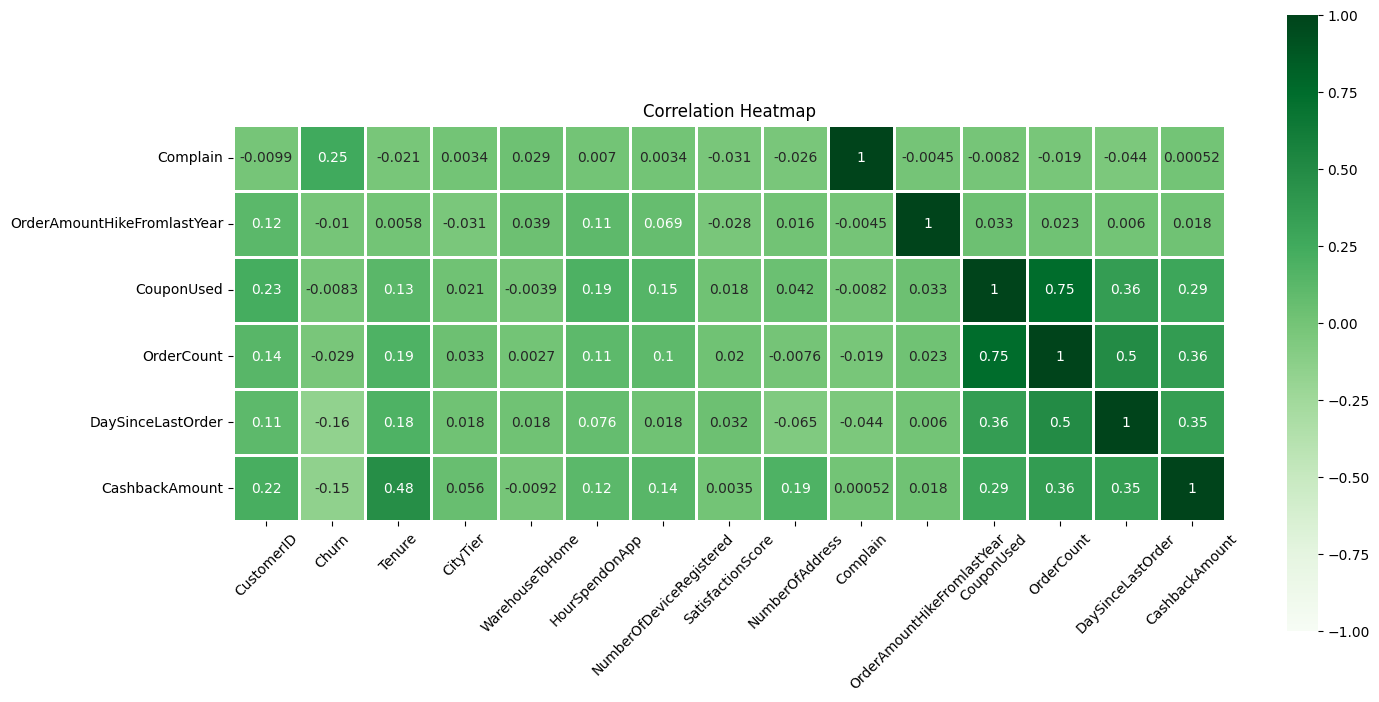

In [ ]:
plt.figure(figsize=(16,8))

sns.heatmap(data=corr[9:],
            cmap="Greens",
            linewidths=1,
            annot=True, # annot	Kataklarda raqamni yozish (True yoki False)
            vmax=1,
            vmin=-1,
            center=0,
            square=True)

plt.title("Correlation Heatmap")
plt.xticks(rotation=45)
plt.show()

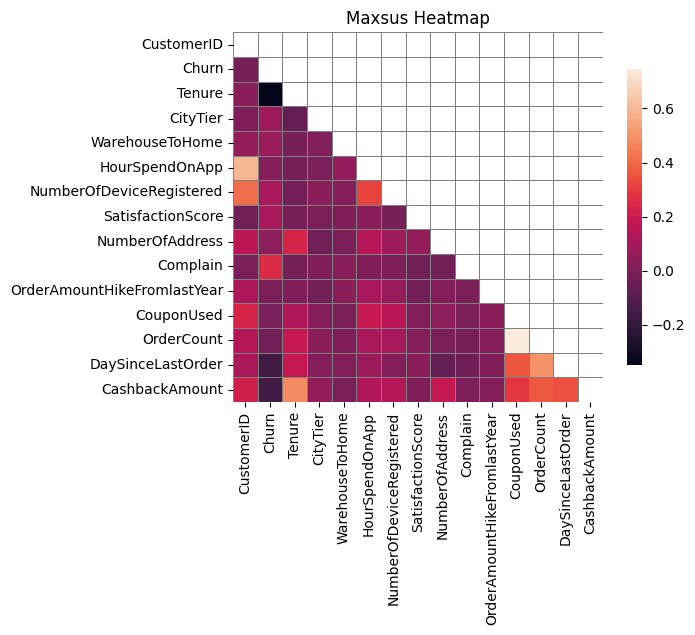

In [ ]:
sns.heatmap(
    corr,
    annot=False,
    fmt=".2f",
    cmap="rocket",
    linewidths=0.5,
    linecolor='gray',
    cbar=True,  # cbar	Rangli shkala ko‘rsatilsinmi? (True yoki False)
    square=True,  # square	Kataklar kvadrat shaklda chiqsinmi? (True/False)
    xticklabels=True,
    yticklabels=True,
    mask=np.triu(np.ones_like(corr, dtype=bool)),  # Diagonal usti yashirin
    cbar_kws={"shrink": 0.8, "orientation": "vertical"},  # Rang shkalasi sozlamalari
    annot_kws={"size": 8, "color": "white"}  # Annot fonti
)
plt.title("Maxsus Heatmap")
plt.show()

Outlierlarni ko'ramiz

In [ ]:
fig = px.box(
    df,
    x="CashbackAmount",
    color="Gender",
    color_discrete_sequence=['crimson', 'teal'],
    template='plotly_dark',
    notched=True
)

fig.show()

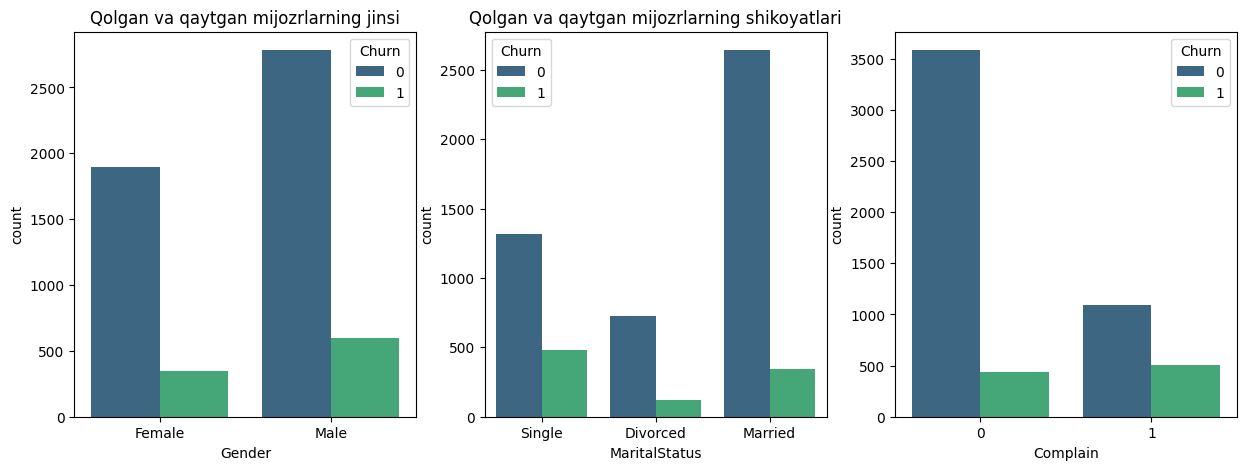

In [ ]:
#Kategoriyali ustunlarni tahlil qilamiz

fig, axes = plt.subplots(1,3, figsize=(15,5))

sns.countplot(x='Gender', hue='Churn', palette='viridis', data=df, ax=axes[0])
axes[0].set_title("Qolgan va qaytgan mijozrlarning jinsi")

sns.countplot(x='MaritalStatus', hue='Churn', palette='viridis', data=df, ax=axes[1])
axes[1].set_title("Qolgan va qaytgan mijozrlarning oilaviy xolati")

sns.countplot(x='Complain', hue='Churn', palette='viridis', data=df, ax=axes[2])
axes[1].set_title("Qolgan va qaytgan mijozrlarning shikoyatlari")

plt.show()

In [ ]:
df.corrwith(df['Churn'], numeric_only=True).abs().sort_values(ascending=False)

,0
Churn,1.000000
Tenure,0.349408
Complain,0.250188
DaySinceLastOrder,0.160757
CashbackAmount,0.154118
NumberOfDeviceRegistered,0.107939
SatisfactionScore,0.105481
CityTier,0.084703
WarehouseToHome,0.076630
NumberOfAddress,0.043931


In [ ]:
#df dagi mavjud bo'lmagan qiymatlar soni
print(f"Mavjud bo'lmagan qiymatlar soni: {df.isnull().sum().sum()}")
#mavjud bo'lmagan qatorlar soni
missing_rows = df[df.isnull().any(axis=1)].shape[0]
print(f"Mavjud bo'lmagan qatorlar soni: {missing_rows}")
#qatorlar nisbati
print(f"Mavjud bo'lmagan qatorlar %: {np.round(missing_rows/len(df)*100)}%")

Mavjud bo'lmagan qiymatlar soni: 1856
Mavjud bo'lmagan qatorlar soni: 1856
Mavjud bo'lmagan qatorlar %: 33.0%


In [ ]:
data = df[['Churn','Tenure','Complain','DaySinceLastOrder','CashbackAmount','MaritalStatus','Gender']]

print(f"Mavjud bo'lmagan qiymatlar soni: {data.isnull().sum().sum()}")
#mavjud bo'lmagan qatorlar soni
missing_rows = data[data.isnull().any(axis=1)].shape[0]
print(f"Mavjud bo'lmagan qatorlar soni: {missing_rows}")
#qatorlar nisbati
print(f"Mavjud bo'lmagan qatorlar %: {np.round(missing_rows/len(data)*100)}%")

Mavjud bo'lmagan qiymatlar soni: 571
Mavjud bo'lmagan qatorlar soni: 571
Mavjud bo'lmagan qatorlar %: 10.0%


In [ ]:
data = data.dropna()
data.shape

(5059, 7)

In [ ]:
data['Churn'].value_counts()/len(data)

Churn
0    0.839296
1    0.160704
Name: count, dtype: float64

In [ ]:
# Matnli ustunlarni songa o'tkazamiz
encoded = pd.get_dummies(data)
encoded.head()

,Churn,Tenure,Complain,DaySinceLastOrder,CashbackAmount,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,Gender_Female,Gender_Male
0,1,4.0,1,5.0,159.93,False,False,True,True,False
3,1,0.0,0,3.0,134.07,False,False,True,False,True
4,1,0.0,0,3.0,129.60,False,False,True,False,True
5,1,0.0,1,7.0,139.19,False,False,True,True,False
8,1,13.0,1,2.0,126.83,True,False,False,False,True


In [ ]:
encoded.corrwith(encoded['Churn']).abs().sort_values(ascending=False)

Churn                     1.000000
Tenure                    0.353464
Complain                  0.245175
MaritalStatus_Single      0.180136
CashbackAmount            0.153990
MaritalStatus_Married     0.151887
DaySinceLastOrder         0.149229
Gender_Female             0.023885
Gender_Male               0.023885
MaritalStatus_Divorced    0.022672
dtype: float64

In [ ]:
X = encoded.drop("Churn", axis=1)
y = encoded['Churn']

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, stratify=y, random_state=12)

Logistic Regression

              precision    recall  f1-score   support

           0       0.88      0.98      0.93       849
           1       0.77      0.30      0.43       163

    accuracy                           0.87      1012
   macro avg       0.82      0.64      0.68      1012
weighted avg       0.86      0.87      0.85      1012

Model aniqligi: 0.8725296442687747


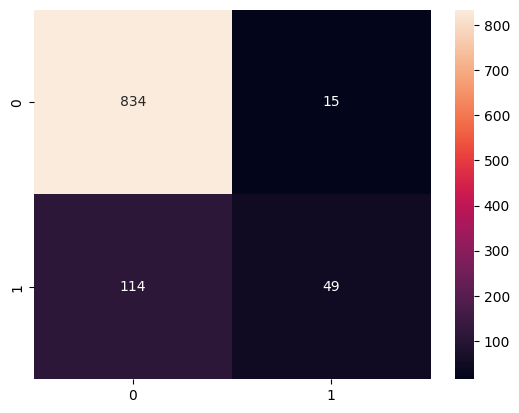

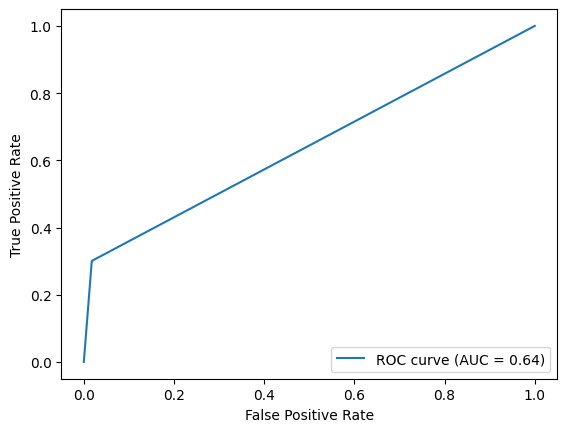

In [ ]:
# Modelni yaratamiz (training)
LR_model = LogisticRegression()
LR_model.fit(X_train, y_train)

# Modelni baholaymiz
y_pred = LR_model.predict(X_test)
print(metrics.classification_report(y_test, y_pred))
print("Model aniqligi:", metrics.accuracy_score(y_test,y_pred))

## confusion matrix
conf_mat = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True,fmt="g")
plt.show()

## ROC curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='ROC curve')
display.plot()
plt.show()

**Support Vector Machine ->SVM**

              precision    recall  f1-score   support

           0       0.87      0.98      0.92       849
           1       0.72      0.23      0.35       163

    accuracy                           0.86      1012
   macro avg       0.79      0.61      0.64      1012
weighted avg       0.85      0.86      0.83      1012

Model aniqligi: 0.8616600790513834


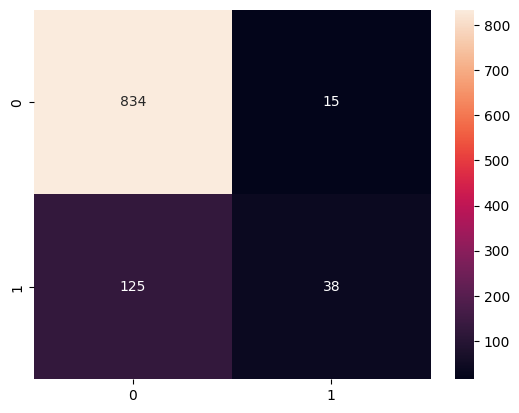

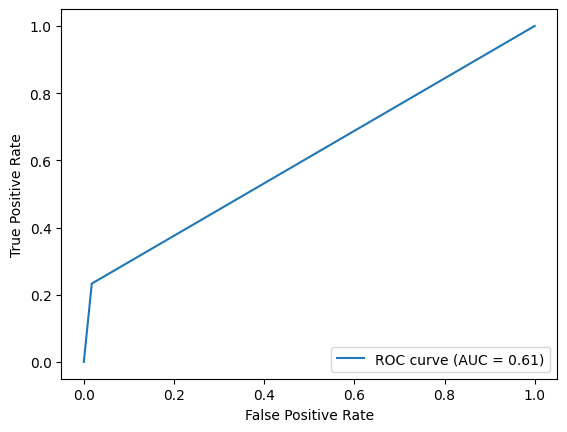

In [ ]:
# Modelni yaratamiz (training)
svm_model = SVC()
svm_model.fit(X_train, y_train)

# Modelni baholaymiz
y_pred = svm_model.predict(X_test)
print(metrics.classification_report(y_test, y_pred))
print("Model aniqligi:", metrics.accuracy_score(y_test,y_pred))

## confusion matrix
conf_mat = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True,fmt="g")
plt.show()

## ROC curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='ROC curve')
display.plot()
plt.show()

**Decision Tree**

              precision    recall  f1-score   support

           0       0.97      0.96      0.97       849
           1       0.81      0.86      0.84       163

    accuracy                           0.95      1012
   macro avg       0.89      0.91      0.90      1012
weighted avg       0.95      0.95      0.95      1012

Model aniqligi: 0.9456521739130435


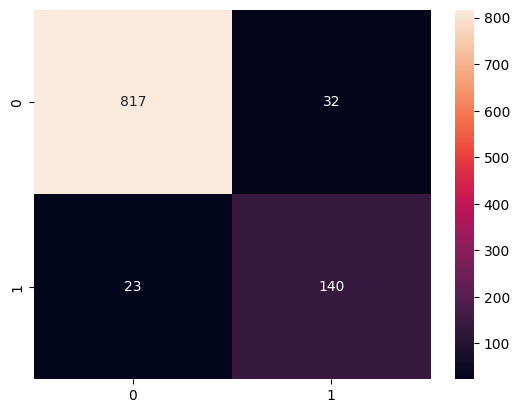

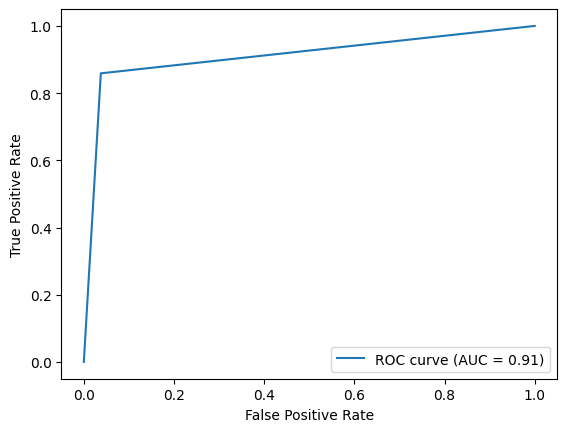

In [ ]:
# Modelni yaratamiz (training)
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)

# Modelni baholaymiz
y_pred = tree_model.predict(X_test)
print(metrics.classification_report(y_test, y_pred))
print("Model aniqligi:", metrics.accuracy_score(y_test,y_pred))

## confusion matrix
conf_mat = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True,fmt="g")
plt.show()

## ROC curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='ROC curve')
display.plot()
plt.show()

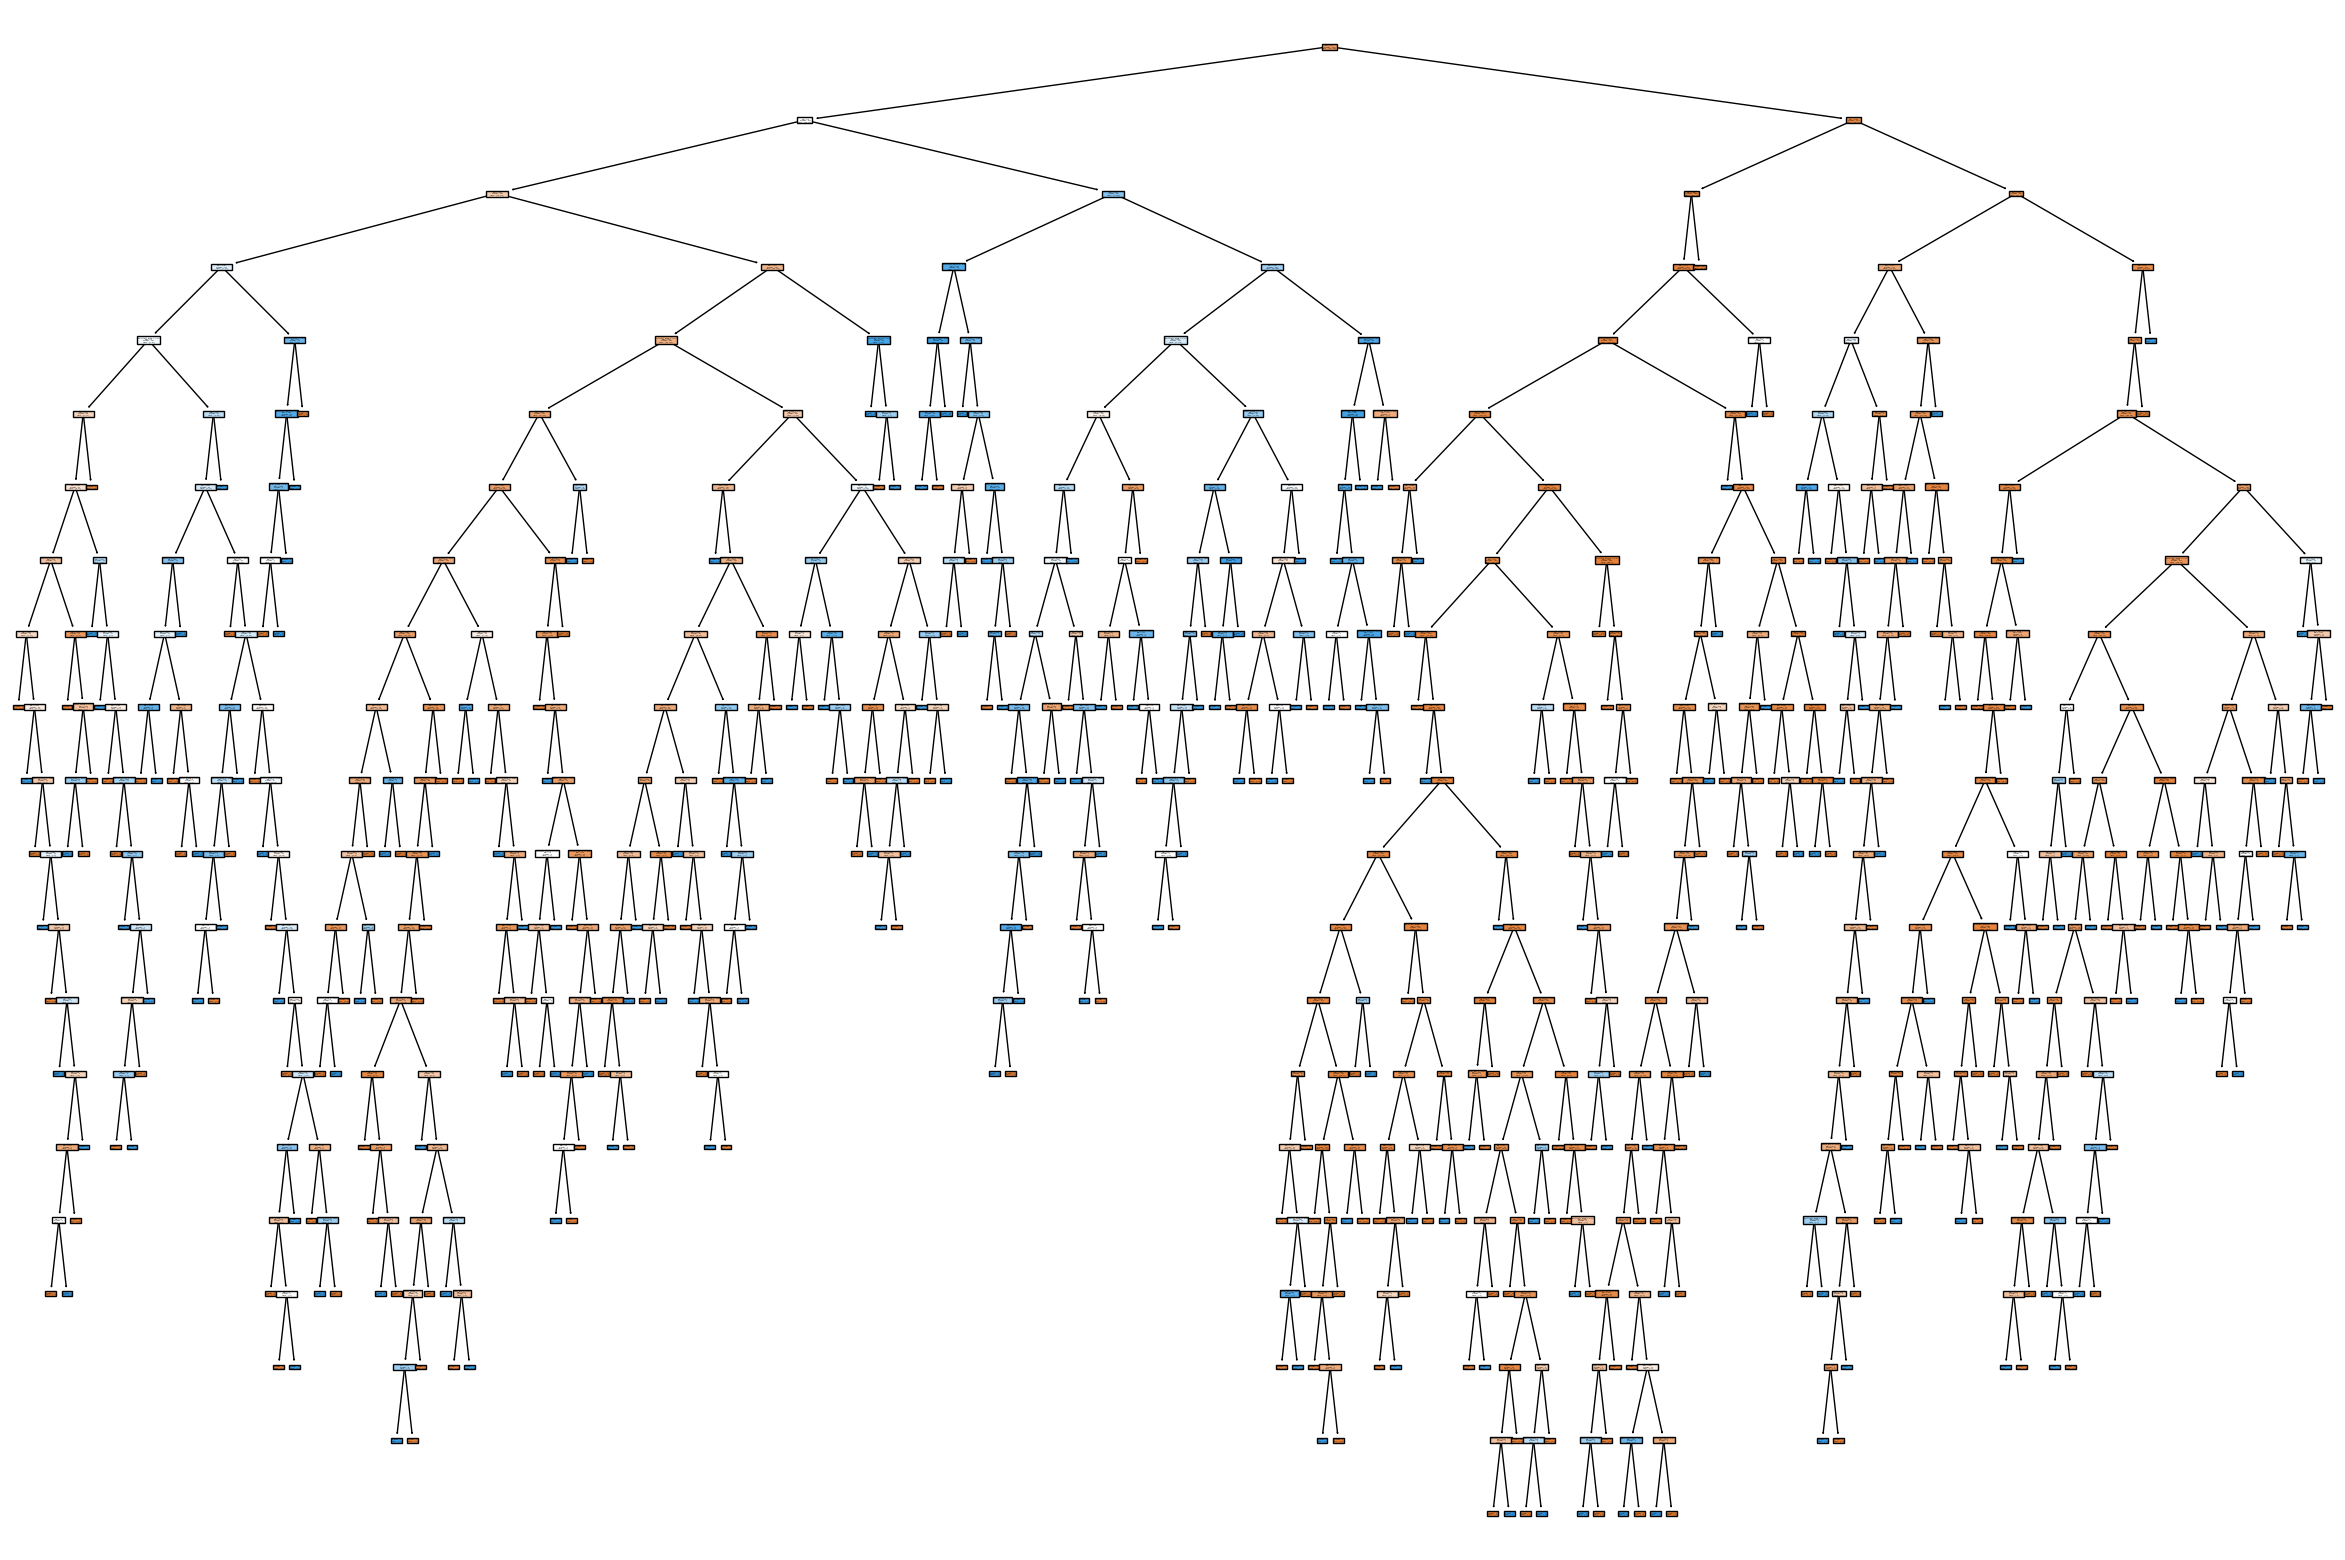

In [ ]:
cols = encoded.drop('Churn', axis=1).columns

plt.figure(figsize=(30,20))
plot_tree(tree_model, feature_names=cols, filled=True)
plt.show()

**XGBoost**

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       849
           1       0.86      0.76      0.81       163

    accuracy                           0.94      1012
   macro avg       0.91      0.87      0.89      1012
weighted avg       0.94      0.94      0.94      1012

Model aniqligi: 0.941699604743083


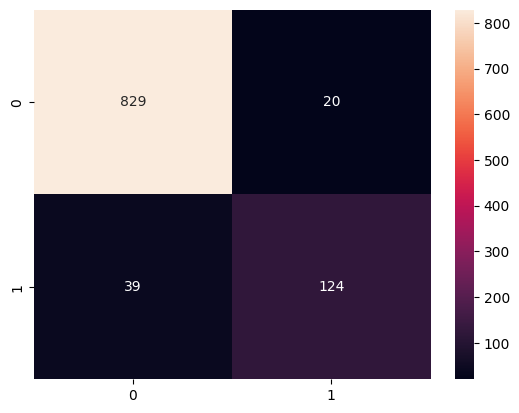

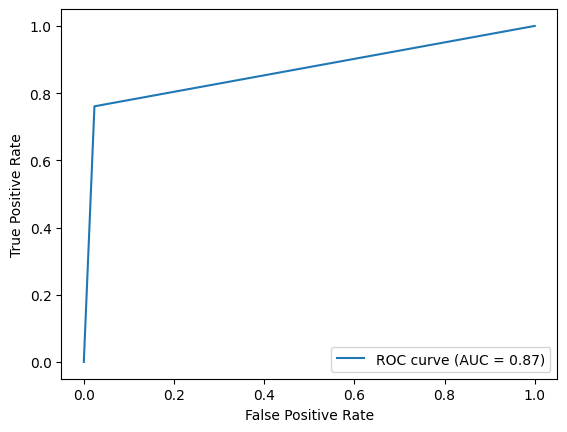

In [ ]:
# Modelni yaratamiz (training)
xgb_model = XGBClassifier()
xgb_model.fit(X_train, y_train)

# Modelni baholaymiz
y_pred = xgb_model.predict(X_test)
print(metrics.classification_report(y_test, y_pred))
print("Model aniqligi:", metrics.accuracy_score(y_test,y_pred))

## confusion matrix
conf_mat = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True,fmt="g")
plt.show()

## ROC curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='ROC curve')
display.plot()
plt.show()

# Eng yaxshi natija DecisionTree Modelida 94.5 % aniqlikda ishladi